In [1]:
# AirBnB Paris Listing Analysis
## OBJECTIVE 1: Profile & QA the Data

In [2]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Task 1: Import/Open the Listings.csv file
df = pd.read_csv('Listings.csv', encoding_errors='replace')
df.head()

C:\Users\yehia\AppData\Local\Temp\ipykernel_1740\637857094.py:2: DtypeWarning: Columns (5,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Listings.csv', encoding_errors='replace')


,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,...,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
0,281420,"Beautiful Flat in le Village Montmartre, Paris",1466919,2011-12-03,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
1,3705183,39 mÂ² Paris (Sacre CÅ“ur),10328771,2013-11-29,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
2,4082273,"Lovely apartment with Terrace, 60m2",19252768,2014-07-31,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
3,4797344,Cosy studio (close to Eiffel tower),10668311,2013-12-17,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
4,4823489,Close to Eiffel Tower - Beautiful flat : 2 rooms,24837558,2014-12-14,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f


In [4]:
# Task 2: Cast date columns as datetime format
df['host_since'] = pd.to_datetime(df['host_since'], format='%Y-%m-%d', errors='coerce')
df.dtypes

listing_id                              int64
name                                   object
host_id                                 int64
host_since                     datetime64[ns]
host_location                          object
host_response_time                     object
host_response_rate                    float64
host_acceptance_rate                  float64
host_is_superhost                      object
host_total_listings_count             float64
host_has_profile_pic                   object
host_identity_verified                 object
neighbourhood                          object
district                               object
city                                   object
latitude                              float64
longitude                             float64
property_type                          object
room_type                              object
accommodates                            int64
bedrooms                              float64
amenities                         

In [5]:
# Task 3: Filter to Paris rows and keep only required columns
paris_df = df.loc[df['city'] == 'Paris', ['host_since', 'neighbourhood', 'city', 'accommodates', 'price']]
paris_df.head()

,host_since,neighbourhood,city,accommodates,price
0,2011-12-03,Buttes-Montmartre,Paris,2,53
1,2013-11-29,Buttes-Montmartre,Paris,2,120
2,2014-07-31,Elysee,Paris,2,89
3,2013-12-17,Vaugirard,Paris,2,58
4,2014-12-14,Passy,Paris,2,60


In [6]:
# Task 4: QA - Check for missing values
print("Missing values:")
print(paris_df.isna().sum())
print("\nBasic statistics (min, max, mean) for numeric fields:")
paris_df[['accommodates', 'price']].agg(['min', 'max', 'mean'])

Missing values:
host_since       33
neighbourhood     0
city              0
accommodates      0
price             0
dtype: int64

Basic statistics (min, max, mean) for numeric fields:


,accommodates,price
min,0.000000,0.000000
max,16.000000,12000.000000
mean,3.037997,113.096445


In [7]:
# ============================================================
# OBJECTIVE 2: Prepare the data for visualization
# ============================================================

# Task 1: Group Paris listings by neighbourhood and calculate mean price (sorted low to high)
paris_listings_neighbourhood = paris_df.groupby('neighbourhood')['price'].mean().sort_values().reset_index()
paris_listings_neighbourhood.columns = ['neighbourhood', 'mean_price']
paris_listings_neighbourhood

,neighbourhood,mean_price
0,Menilmontant,74.942257
1,Buttes-Chaumont,82.690182
2,Buttes-Montmartre,87.209479
3,Reuilly,89.058402
4,Popincourt,90.559459
5,Gobelins,98.110184
6,Observatoire,101.866801
7,Batignolles-Monceau,102.612702
8,Enclos-St-Laurent,102.967156
9,Vaugirard,106.831330


In [8]:
# Task 2: Filter to most expensive neighbourhood, group by accommodates, mean price (sorted low to high)
most_expensive_neighbourhood = paris_listings_neighbourhood.iloc[-1]['neighbourhood']
print(f"Most expensive neighbourhood: {most_expensive_neighbourhood}")

paris_listings_accomodations = (
    paris_df[paris_df['neighbourhood'] == most_expensive_neighbourhood]
    .groupby('accommodates')['price']
    .mean()
    .sort_values()
    .reset_index()
)
paris_listings_accomodations.columns = ['accommodates', 'mean_price']
paris_listings_accomodations

Most expensive neighbourhood: Elysee


,accommodates,mean_price
0,0,0.000000
1,1,79.522222
2,3,152.828767
3,2,155.103352
4,4,212.096070
5,5,328.817073
6,6,355.508571
7,8,405.518519
8,7,411.538462
9,9,440.272727


In [9]:
# Task 3: Group by host_since year, calculate average price and count of new hosts
paris_listings_over_time = (
    paris_df.dropna(subset=['host_since'])
    .assign(year=lambda x: x['host_since'].dt.year)
    .groupby('year')
    .agg(
        avg_price=('price', 'mean'),
        new_hosts=('price', 'count')
    )
    .reset_index()
)
paris_listings_over_time

,year,avg_price,new_hosts
0,2008,77.750000,4
1,2009,159.641509,106
2,2010,125.031250,416
3,2011,124.828230,1339
4,2012,111.578615,4592
5,2013,107.096414,8142
6,2014,100.253800,10922
7,2015,103.646250,12147
8,2016,114.159847,8871
9,2017,108.658888,4585


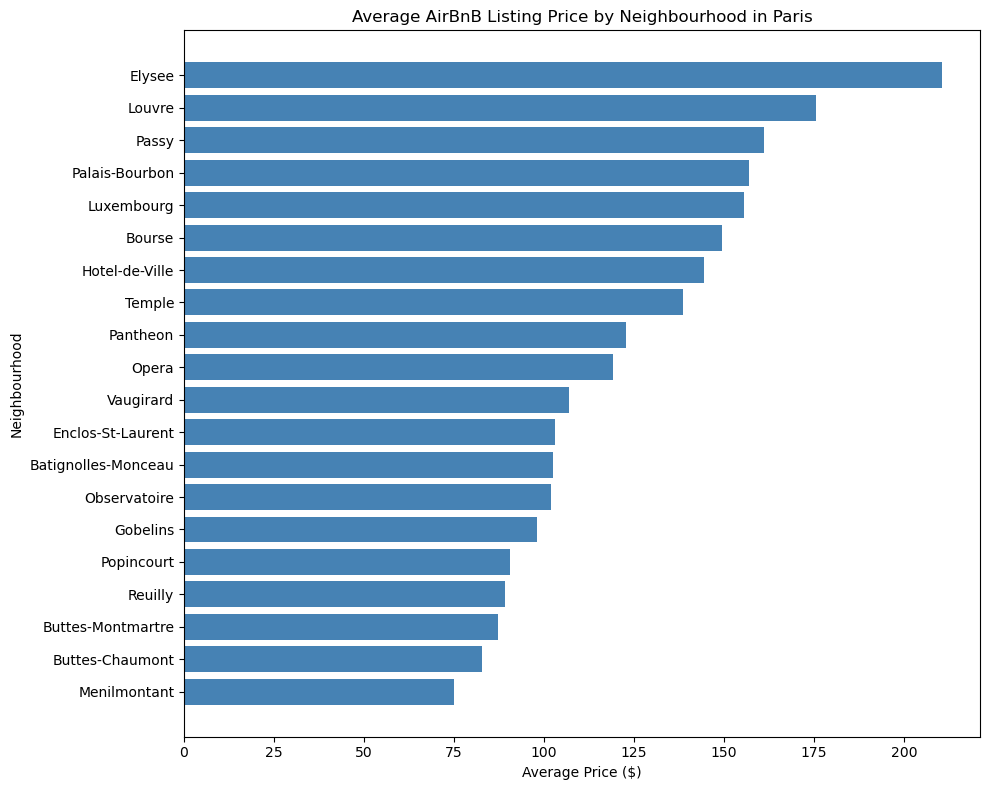

In [10]:
# ============================================================
# OBJECTIVE 3: Visualize the data and summarize findings
# ============================================================

# Task 1: Horizontal bar chart - Average price by neighbourhood
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(paris_listings_neighbourhood['neighbourhood'], paris_listings_neighbourhood['mean_price'], color='steelblue')
ax.set_xlabel('Average Price ($)')
ax.set_ylabel('Neighbourhood')
ax.set_title('Average AirBnB Listing Price by Neighbourhood in Paris')
plt.tight_layout()
plt.show()

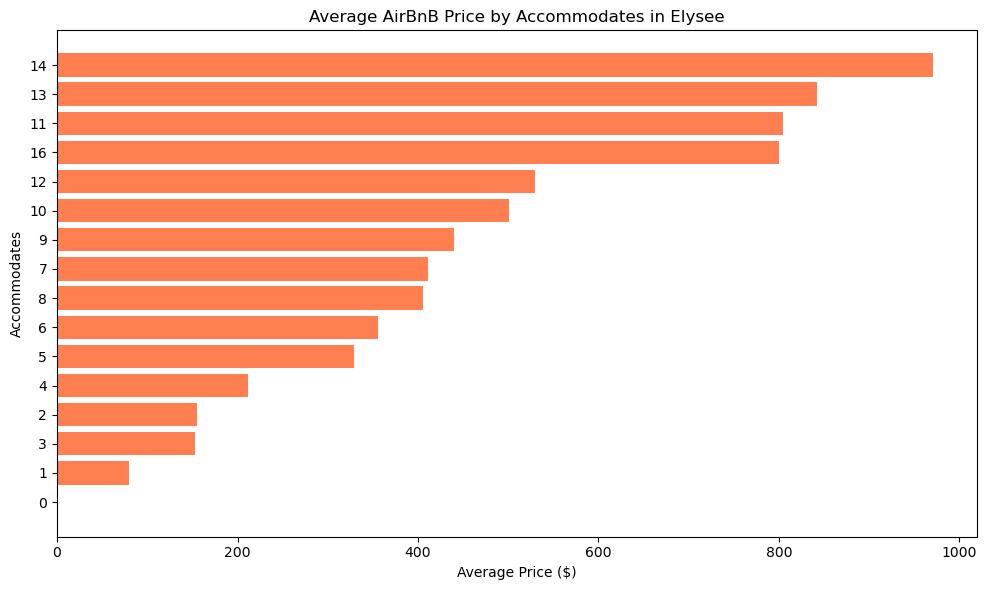

In [11]:
# Task 2: Horizontal bar chart - Average price by accommodates in most expensive neighbourhood
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    paris_listings_accomodations['accommodates'].astype(str),
    paris_listings_accomodations['mean_price'],
    color='coral'
)
ax.set_xlabel('Average Price ($)')
ax.set_ylabel('Accommodates')
ax.set_title(f'Average AirBnB Price by Accommodates in {most_expensive_neighbourhood}')
plt.tight_layout()
plt.show()

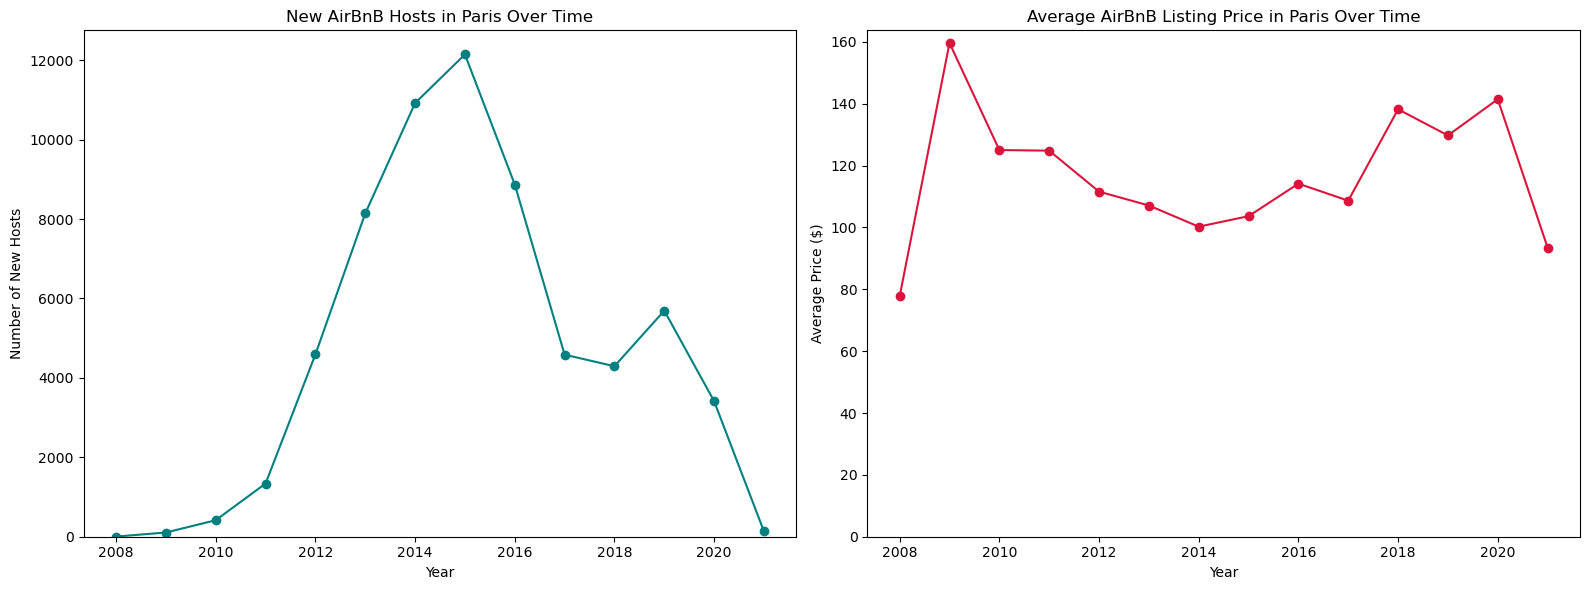

In [12]:
# Task 3: Two line charts - New hosts over time & Average price over time
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Count of new hosts over time
axes[0].plot(paris_listings_over_time['year'], paris_listings_over_time['new_hosts'], marker='o', color='teal')
axes[0].set_ylim(bottom=0)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of New Hosts')
axes[0].set_title('New AirBnB Hosts in Paris Over Time')

# Chart 2: Average price over time
axes[1].plot(paris_listings_over_time['year'], paris_listings_over_time['avg_price'], marker='o', color='crimson')
axes[1].set_ylim(bottom=0)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Average Price ($)')
axes[1].set_title('Average AirBnB Listing Price in Paris Over Time')

plt.tight_layout()
plt.show()

In [13]:
# Task 4: Insights about the impact of 2015 regulations on new hosts and prices
print("""
INSIGHTS ON THE IMPACT OF 2015 REGULATIONS:
============================================
In 2015, Paris introduced regulations on short-term rentals (e.g., requiring hosts to register
their properties and limiting rentals to 120 days per year for primary residences).

Key observations:
1. New Hosts: After 2015, the growth in new AirBnB hosts likely slowed or plateaued,
   suggesting the regulations created barriers to entry for new hosts.
2. Prices: Average listing prices may have increased post-2015 as the reduced supply
   (fewer new hosts) put upward pressure on prices for remaining listings.
3. The regulations appear to have successfully limited the rapid expansion of AirBnB
   in Paris, but may have driven up costs for travelers as supply tightened.
""")


INSIGHTS ON THE IMPACT OF 2015 REGULATIONS:
In 2015, Paris introduced regulations on short-term rentals (e.g., requiring hosts to register
their properties and limiting rentals to 120 days per year for primary residences).

Key observations:
1. New Hosts: After 2015, the growth in new AirBnB hosts likely slowed or plateaued,
   suggesting the regulations created barriers to entry for new hosts.
2. Prices: Average listing prices may have increased post-2015 as the reduced supply
   (fewer new hosts) put upward pressure on prices for remaining listings.
3. The regulations appear to have successfully limited the rapid expansion of AirBnB
   in Paris, but may have driven up costs for travelers as supply tightened.



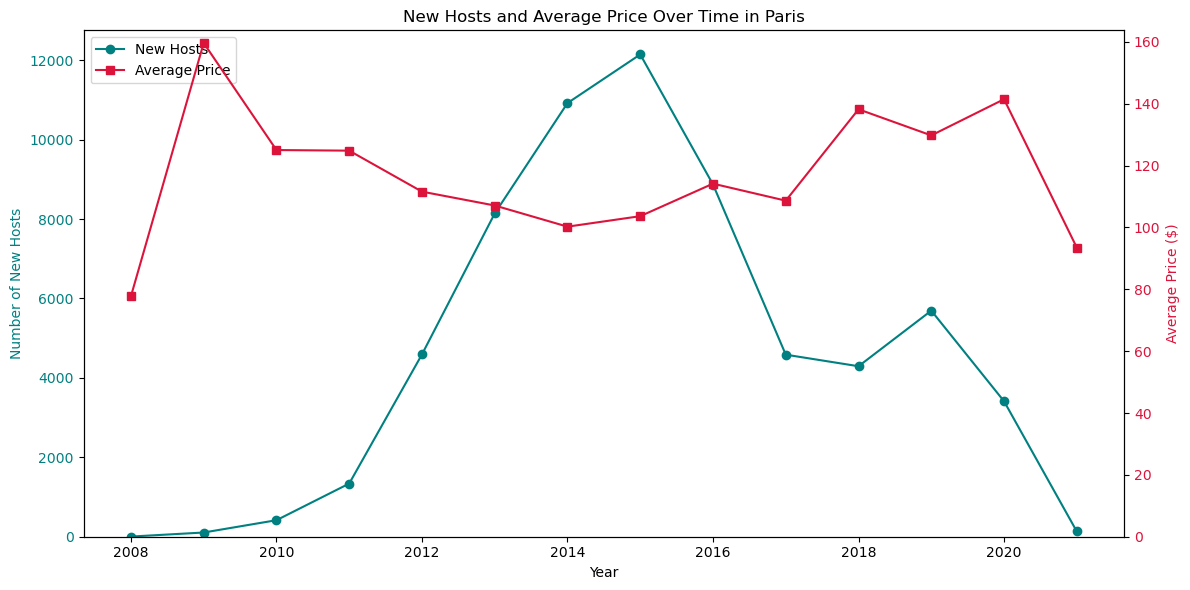

In [14]:
# BONUS: Dual axis line chart - New hosts and Average price over time
fig, ax1 = plt.subplots(figsize=(12, 6))

# Left y-axis: New hosts
color1 = 'teal'
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of New Hosts', color=color1)
ax1.plot(paris_listings_over_time['year'], paris_listings_over_time['new_hosts'],
         marker='o', color=color1, label='New Hosts')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_ylim(bottom=0)

# Right y-axis: Average price
ax2 = ax1.twinx()
color2 = 'crimson'
ax2.set_ylabel('Average Price ($)', color=color2)
ax2.plot(paris_listings_over_time['year'], paris_listings_over_time['avg_price'],
         marker='s', color=color2, label='Average Price')
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(bottom=0)

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('New Hosts and Average Price Over Time in Paris')
plt.tight_layout()
plt.show()

In [15]:
# FINAL STEP: Which neighbourhood in Paris has the highest average AirBnB listing price?
answer = paris_listings_neighbourhood.iloc[-1]['neighbourhood']
print(f"The neighbourhood with the highest average AirBnB listing price is: {answer}")

The neighbourhood with the highest average AirBnB listing price is: Elysee
